## This is a sample Machine Learning project that exemplifies how to proceed Linear Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Pingouin, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from statstests.process import stepwise
import networkx as nx
import pingouin as pg
import seaborn as sns
import plotly.graph_objects as go
import os
import plotly.io as pio
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - CPI = f(region). Multiple Linear Regression.

This is another use-case for Generalized Linear Models (GLMs), in this case, of type Multiple Linear Regression (SLR). Here, we adapt and reuse the CPI example, from another use-case, at this same project repository, but having only one single explicative variable that, here, is a qualitative one (region). When having qualitative variables, and if we want to use them at our regression analysis model, without arbitrary weighting, we must transform those variables into multiple dummy vabriables, according to the number of categories: n-1 dummy variables, n being the number of categories for each qualitative variable. This example is mainly for demonstrating the dummyzation process. For other advanced linear regression analysis, including multicollinearity and heteroscedasticity diagnostics, stepwise method, adherence of residuals to normality (shapiro-francia) and normalization techniques (Box-Cox), check out other examples at this same project directory.

In [2]:
# reading and displaying our dataset
# the country column is just a label (id) column, so that we have only cpi and region as dependent and explicative variables, 
# respectively. As we cant proceed linear regression with qualitative vabriables, we must perform the dummyzation process, first.
cpi_df = pd.read_csv('cpi2.csv', delimiter=',', encoding="utf-8")
cpi_df

,country,cpi,region
0,Argentina,3.9,South_America
1,Australia,8.7,Oceania
2,Austria,7.9,Europe
3,Belgium,7.1,Europe
4,Brazil,4.0,South_America
5,Canada,8.9,USA_Canada
6,Chile,6.2,South_America
7,China,2.5,Asia
8,Colombia,4.0,South_America
9,Cyprus,6.3,Europe


In [3]:
cpi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  50 non-null     str    
 1   cpi      50 non-null     float64
 2   region   50 non-null     str    
dtypes: float64(1), str(2)
memory usage: 1.3 KB


In [4]:
cpi_df.describe()

,cpi
count,50.000000
mean,4.894000
std,2.678974
min,0.800000
25%,2.575000
50%,3.950000
75%,7.475000
max,9.300000


In [5]:
cpi_df.groupby("region").describe()

cpi                                                  
              count      mean       std  min    25%   50%    75%  max
region                                                               
Asia           17.0  2.329412  0.898446  0.8  1.800  2.30  2.800  3.8
Europe         24.0  6.258333  2.272504  2.1  4.275  6.55  8.125  9.3
Oceania         2.0  9.000000  0.424264  8.7  8.850  9.00  9.150  9.3
South_America   5.0  4.180000  1.237740  2.8  3.900  4.00  4.000  6.2
USA_Canada      2.0  8.000000  1.272792  7.1  7.550  8.00  8.450  8.9

In [6]:
counting_df = cpi_df["region"].value_counts(dropna=False)
percent_df = cpi_df["region"].value_counts(dropna=False, normalize=True)
print(counting_df)
print(f"\n{percent_df}")

region
Europe           24
Asia             17
South_America     5
Oceania           2
USA_Canada        2
Name: count, dtype: int64

region
Europe           0.48
Asia             0.34
South_America    0.10
Oceania          0.04
USA_Canada       0.04
Name: proportion, dtype: float64


In [7]:
pd.concat([counting_df, percent_df], axis=1, keys=['counting','%'], sort=False)

,counting,%
region,,
Europe,24,0.48
Asia,17,0.34
South_America,5,0.10
Oceania,2,0.04
USA_Canada,2,0.04


Dummy variables are binary qualitative (categorical) vabriables that have only two categories as values: 0 or 1. After we proceed the dummyzation process, also known as one-hot encoding, for all qualitative variables, in a SLR or MLR model, we define the regression model parameters as usual, for the quantitative vabriables, but, for the qualitative variables, we omit the original ones and use their dummy variables instead, so that, for each original category of each qualitative variable, we have only 0 or 1 as inputs, along with the respective betas (angular values). So, the betas are discovered along with the OLS regression process, and the inputs for each dummy variable varies according to each observation: if the category (feature) is present, for each subject, its dummy input is 1, if it's not, it's dummy input is 0. This way, each observation (row) may have its own individual dependent variable value. 

The dummyzation process, or one-hot encoding, must consider one of the categories as the reference variable, and the beta of all others will be adjusted relatively to the reference one (actually according to the dependent variable's value when only the reference dummy is present). The reference variable won't be displayed at the regression expression, 'cause its value will be the alfa (or part of the alfa, if quantitative variables are also present). All other dummy variables will appear at the regression expression (with either 1 or 0 as inputs). In case we have no quantitative variables (as in this example case), and in case all other dummy vabriables have 0 as inputs for a certain observation, what remains is the alfa value that is the value of the dependent variable when only the reference variable is present. If other dummy variables are also present (=1), they'll summate to the reference value (alfa) to yield the final dependent value for that observation. The reference variable is thus inferred from the 0 values at all other related dummy variables, and is the baseline, relative to which the other dummy variables have their beta calculated from - adding or subtracting from that baseline reference value. We can manually set different dummy variables to be the reference one, but that won't change the regression results (only the alfa and relative dummy betas), so, by default, the first category is set as the reference dummy variable.

In our case, we have only one explicative variable, the qualitative "region" variable, with 5 categories. As just explained, we'll have thus 1 reference category as the reference dummy variable, which is going to be omitted from the model expression, and the other 4 categories (D1, D2, D3 and D4 below) will be dummy variables whose beta values will be calculated relatively to the value of the dependent variable when only the reference dummy value (the alfa) is present:

Yi = alfa + β1​D1i + β2​D2i​ + β3​D3i​ + β4​D4i​ + ε

One could think it is a SLR use-case, but, after we separate the categories of that single qualitative variable into many dummy variables, and send these to the model definition method, that's in fact a case of Multiple Linear Regression (MLR). We deal with the multiple dummy variables and not with the single original qualitative variable anymore

Another confusion that may appear, is whether the model is actually a linear model, as all explicative variables, in this use-case, are discrete in their inputs (0 or 1). The model is linear, in its parameters, as each coefficient enters only as a first-degree term (no products, powers, or nonlinear transformations of the coefficients). What makes the model linear are the betas, even though the result of each factor, between them, is discrete. You're simply comparing dependent variable' values for the different categories, accordingn at each observation.

It's absolutely WRONG to do any arbitrary weighting on qualitative variables (for instance, by quantifying or ordering the categories as 1, 2, 3, 4 and 5), and the dummyzation process avoids that. In arbitrary weighting, you set arbitrary quantitative values, generating order and space between categories, as well as position and dispersion properties (e.g. mean and standard deviation), that cannot exist in categorical data (only frequency counting shall exist). By using dummy variables, on the contrary, what you do is simply create a binary "switch" (or flag), that is not a numerical number, but a label, and the betas are values relative to the base value of the dependent variable when you only have the alfa, i.e., the reference dummy variable (with all other dummies = 0). So, we do not create arbitrary quantities for or between categories... we just separate them into individual dummy variables and consider the dependent variable's value as different values, according to what dummy variables are present (1) or not (0), at each observation. The reference variable turns out to be the alfa of the expression, and is represented in all observations, summed up to or subtracted from the other dummy variables' beta.

In [8]:
# The method below does the following:
# - creates the dummy variables for all qualitative variables' categories (in this case 1 qualitative variable with 5 categories)
# - removes the original qualitative variable, letting only its dummy derived variables
# - sets the first of the dummies as the reference, if it is set drop_first=True
cpi_dummies_df = pd.get_dummies(cpi_df, columns=["region"], dtype=int, drop_first=True)
cpi_dummies_df

# in this case, region_Asia is the category took as dummy reference from the region qualitative variable
# For instance, at index 7, for country=China, we have inputs 0 for all shown dummies, and a dependent value eq 2.5, which, 
# therefore is the value of the dependent variable when only the region_Asia has input 1, that is, when you only have the alfa, 
# and all other dummies' inputs are 0. 2.5 is thus the value of alfa, and the value of the region_Asia beta - but, as the 
# reference variable, region_Asia is omitted and inferred by the 0 value of all other dummies' inputs. When other dummies' inputs
# are 1, then their betas summate to the baseline alfa to give a distinct dependent value for that other observation, and so on.
# In the case of country=Argentina, we have region_South_America=1, other shown dummies 0, and the alfa is fixed as 2.5. So the
# region_South_America beta is 1.4. 

# In reality, this is not true, as the observed values are different from the fitted values. Actually, for each observed value 
# below, we also have a residual value, so each dependent value will vary a bit, even when all dummies are 0 - the fitted alfa 
# is actually 2.3294, as we can see at the model summary below.

# Having the alfa and the betas of each dummy variable, you may write the regression expression for predicting the dependent
# variable's value at any new observation. We'll of course let the OLS algorithm do that for us, specially because of the 
# residuals, and also by the fact that we could be working with thousands of variables and categories, which turns it hard to 
# calculate the regression (fitted) parameters by hand.

,country,cpi,region_Europe,region_Oceania,region_South_America,region_USA_Canada
0,Argentina,3.9,0,0,1,0
1,Australia,8.7,0,1,0,0
2,Austria,7.9,1,0,0,0
3,Belgium,7.1,1,0,0,0
4,Brazil,4.0,0,0,1,0
5,Canada,8.9,0,0,0,1
6,Chile,6.2,0,0,1,0
7,China,2.5,0,0,0,0
8,Colombia,4.0,0,0,1,0
9,Cyprus,6.3,1,0,0,0


In [9]:
# now we may define the regression model
# observe that F and all variables t tests are significant, so we keep them all. We now have the alfa and each beta for our
# dummy variables.

cpi_dummies_model = sm.OLS.from_formula("cpi ~ region_Europe + region_Oceania + region_South_America + region_USA_Canada",
                                        cpi_dummies_df).fit()
cpi_dummies_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cpi   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     17.09
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.37e-08
Time:                        14:14:42   Log-Likelihood:                -96.620
No. Observations:                  50   AIC:                             203.2
Df Residuals:                      45   BIC:                             212.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.3294      0.427      5.453      0.000       1.469       3.190
region_Europe            3.9289      0.558      7.036      0.000       2.804       5.054
region_Oceania           6.6706      1.317      5.066      0.000       4.018       9.323
region_South_America     1.8506      0.896      2.065      0.045       0.046       3.655
region_USA_Canada        5.6706      1.317      4.306      0.000       3.018       8.323
==============================================================================
Omnibus:                        1.205   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.547   Jarque-Bera (JB):                1.083
Skew:                          -0.347   Prob(JB):                        0.582
Kurtosis:                       2.804   Cond. No.                         6.58
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
# for many dummy variables, we may create the formula argument of the OLS method as below:
column_list =list(cpi_dummies_df.drop(columns=['cpi','country']).columns)
formula_dummies = ' + '.join(column_list)
formula_dummies = "cpi ~ " + formula_dummies
print("Formula complete: ",formula_dummies)

# defining the model and showing the stats
cpi_dummies_model = sm.OLS.from_formula(formula_dummies,
                                        cpi_dummies_df).fit()
cpi_dummies_model.summary()

Formula complete:  cpi ~ region_Europe + region_Oceania + region_South_America + region_USA_Canada


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cpi   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     17.09
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.37e-08
Time:                        14:14:42   Log-Likelihood:                -96.620
No. Observations:                  50   AIC:                             203.2
Df Residuals:                      45   BIC:                             212.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.3294      0.427      5.453      0.000       1.469       3.190
region_Europe            3.9289      0.558      7.036      0.000       2.804       5.054
region_Oceania           6.6706      1.317      5.066      0.000       4.018       9.323
region_South_America     1.8506      0.896      2.065      0.045       0.046       3.655
region_USA_Canada        5.6706      1.317      4.306      0.000       3.018       8.323
==============================================================================
Omnibus:                        1.205   Durbin-Watson:                   1.928
Prob(Omnibus):                  0.547   Jarque-Bera (JB):                1.083
Skew:                          -0.347   Prob(JB):                        0.582
Kurtosis:                       2.804   Cond. No.                         6.58
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
# mounting the model equation
params = cpi_dummies_model.params

# printing the params
print(f'alfa (intercept) = {params["Intercept"]}\nbeta1 (region_Europe) = {params["region_Europe"]}\nbeta2 (region_Oceania) = {params["region_Oceania"]}\nbeta3 (region_South_America) = {params["region_South_America"]}\nbeta4 (region_USA_Canada) = {params["region_USA_Canada"]}')

# printing the regression equation
terms = [f"{coef:.4f}*{name}" for name, coef in params.items() if name != "Intercept"]
equation = f"\nCPI = {params['Intercept']:.4f} + " + " + ".join(terms)
print(equation)

alfa (intercept) = 2.32941176470588
beta1 (region_Europe) = 3.928921568627447
beta2 (region_Oceania) = 6.670588235294116
beta3 (region_South_America) = 1.8505882352941154
beta4 (region_USA_Canada) = 5.670588235294119

CPI = 2.3294 + 3.9289*region_Europe + 6.6706*region_Oceania + 1.8506*region_South_America + 5.6706*region_USA_Canada


In [12]:
# With the regression expression above we may predict that:
# - any country in region_Asia (reference dummy) will have a CPI of 2.32+0+0+0+0 = 2.32 = alfa
# - any country in region_Europe will have a CPI of 2.32+3.92*1+0+0+0= 6.24
# - any country in region_Oceania will have a CPI of 2.32+0+6.67*1+0+0= 8.99
# - any country in region_South_America will have a CPI of 2.32+0+0+1.85*1+0= 4.17
# - any country in region_USA_Canada will have a CPI of 2.32+0+0+0+5.67*1= 7.99

# added to the predicted values above, we'll have residuals as well - when dealing with the real (observed) values. But those 
# would be the fitted ones.

In [13]:
# Adding fitted values and residuals to the dummy dataset
cpi_dummies_df['cpi-fitted (Ŷi)'] = cpi_dummies_model.fittedvalues
cpi_dummies_df["residual (ui)"] = cpi_dummies_model.resid
cpi_dummies_df

,country,cpi,region_Europe,region_Oceania,region_South_America,region_USA_Canada,cpi-fitted (Ŷi),residual (ui)
0,Argentina,3.9,0,0,1,0,4.180000,-0.280000
1,Australia,8.7,0,1,0,0,9.000000,-0.300000
2,Austria,7.9,1,0,0,0,6.258333,1.641667
3,Belgium,7.1,1,0,0,0,6.258333,0.841667
4,Brazil,4.0,0,0,1,0,4.180000,-0.180000
5,Canada,8.9,0,0,0,1,8.000000,0.900000
6,Chile,6.2,0,0,1,0,4.180000,2.020000
7,China,2.5,0,0,0,0,2.329412,0.170588
8,Colombia,4.0,0,0,1,0,4.180000,-0.180000
9,Cyprus,6.3,1,0,0,0,6.258333,0.041667


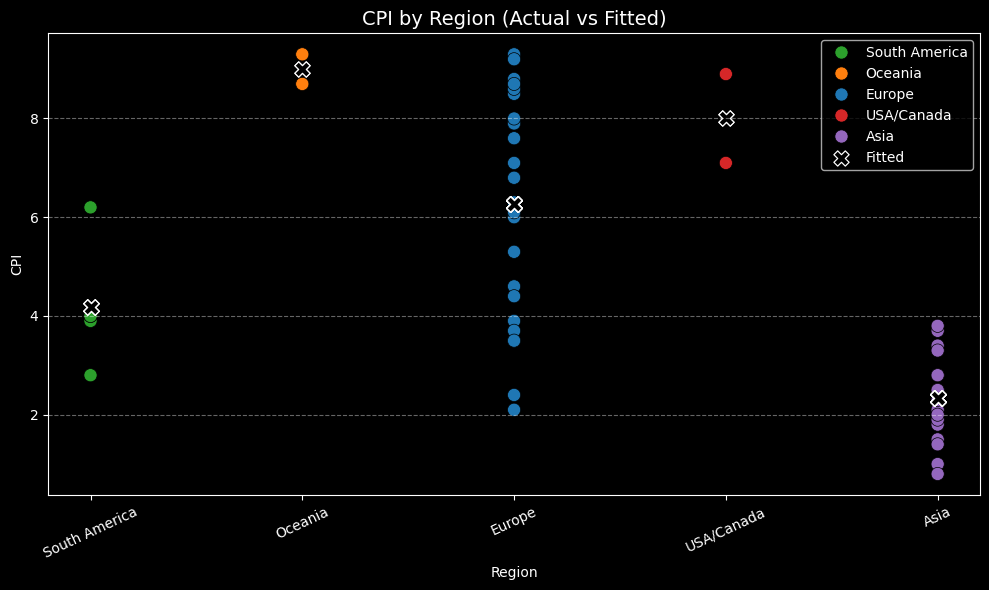

In [14]:
# plotting scatter graph with observed and fitted values for each region
# observe that we do not have a continuous line of CPI, as we actually have discrete CPI values and only at each exact region, not between
# regions. That's the perfect output graph when you plot qualitative instead of quantitative data. And it actually proves we did not
# introduce any arbitrary weighting.

# Define region labels
def get_region(row):
    if row["region_Europe"] == 1:
        return "Europe"
    elif row["region_Oceania"] == 1:
        return "Oceania"
    elif row["region_South_America"] == 1:
        return "South America"
    elif row["region_USA_Canada"] == 1:
        return "USA/Canada"
    else:
        return "Asia"

cpi_dummies_df["region"] = cpi_dummies_df.apply(get_region, axis=1)

# Solid color palette (bold & distinct)
palette = {
    "Europe": "#1f77b4",        # deep blue
    "Oceania": "#ff7f0e",       # orange
    "South America": "#2ca02c", # green
    "USA/Canada": "#d62728",    # red
    "Asia": "#9467bd"          # purple
}

plt.figure(figsize=(10,6))

# Actual values
sns.scatterplot(
    data=cpi_dummies_df,
    x="region",
    y="cpi",
    hue="region",
    palette=palette,
    s=90,
    edgecolor="black",
    linewidth=0.5,
    legend=True
)

# Fitted values (solid black X markers)
sns.scatterplot(
    data=cpi_dummies_df,
    x="region",
    y="cpi-fitted (Ŷi)",
    color="black",
    marker="X",
    s=120,
    label="Fitted"
)

plt.title("CPI by Region (Actual vs Fitted)", fontsize=14)
plt.xlabel("Region")
plt.ylabel("CPI")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

<Axes: xlabel='region', ylabel='cpi'>

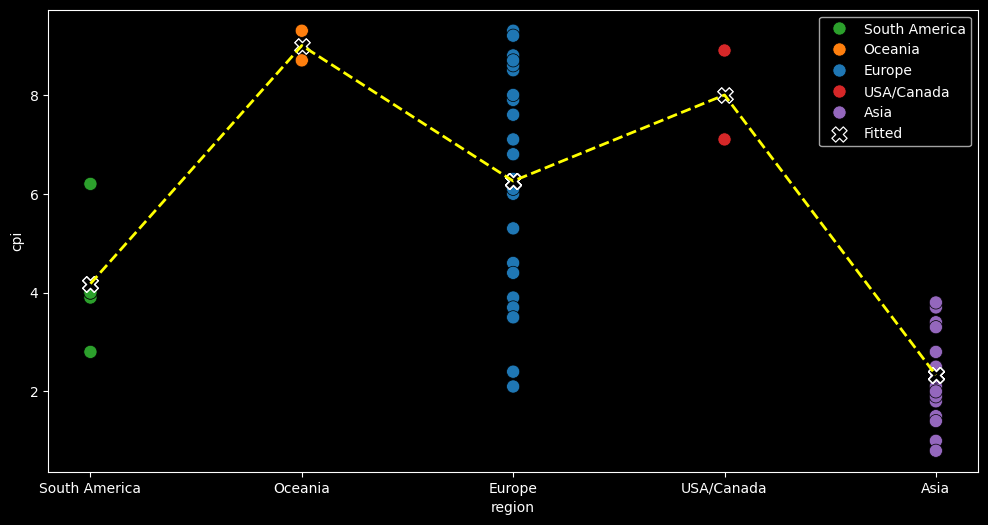

In [15]:
# plotting the same graph above but with a dashed line, linking the discrete non-continuous CPI of each region

# Define region labels
def get_region(row):
    if row["region_Europe"] == 1:
        return "Europe"
    elif row["region_Oceania"] == 1:
        return "Oceania"
    elif row["region_South_America"] == 1:
        return "South America"
    elif row["region_USA_Canada"] == 1:
        return "USA/Canada"
    else:
        return "Asia"

cpi_dummies_df["region"] = cpi_dummies_df.apply(get_region, axis=1)

# Solid color palette (bold & distinct)
palette = {
    "Europe": "#1f77b4",        # deep blue
    "Oceania": "#ff7f0e",       # orange
    "South America": "#2ca02c", # green
    "USA/Canada": "#d62728",    # red
    "Asia": "#9467bd"          # purple
}

plt.figure(figsize=(12,6))

# Actual values
sns.scatterplot(
    data=cpi_dummies_df,
    x="region",
    y="cpi",
    hue="region",
    palette=palette,
    s=90,
    edgecolor="black",
    linewidth=0.5,
    legend=True
)

# Get the x-axis category order from the plot
ax = plt.gca()
labels = [tick.get_text() for tick in ax.get_xticklabels()]

# Compute fitted mean per region in THAT exact order
fitted_by_region = (
    cpi_dummies_df
    .groupby("region")["cpi-fitted (Ŷi)"]
    .mean()
)

# Align values to plotted order
y_values = [fitted_by_region[label] for label in labels]
x_positions = range(len(labels))

# Draw dashed line connecting the X markers
plt.plot(
    x_positions,
    y_values,
    linestyle="--",
    color="yellow",   # better for dark background
    linewidth=2,
    zorder=3
)

sns.scatterplot(
    data=cpi_dummies_df,
    x="region",
    y="cpi-fitted (Ŷi)",
    color="black",
    marker="X",
    s=120,
    label="Fitted"
)